<a href="https://colab.research.google.com/github/barzon1/FarmTech-MachineLearning-Fase5/blob/main/LucasBarzon_rm567914_pbl_fase5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Rendimento Agrícola - FarmTech

Neste projeto, analiso uma base de dados de uma fazenda de médio porte atendida pela FarmTech Solutions. O objetivo é utilizar técnicas de Inteligência Artificial para estudar informações de condições do solo e temperatura relacionadas aos tipos de culturas produzidas.

A partir desses dados, busco prever o rendimento das safras utilizando regressão supervisionada e também explorar padrões e tendências de produtividade por meio de técnicas de aprendizado não supervisionado.

In [1]:
# Importando a biblioteca necessária
import pandas as pd

# Carregando a base de dados (tabela)
tabela_fazenda = pd.read_csv('crop_yield.csv')

# Exibindo as 5 primeiras linhas da tabela
display(tabela_fazenda.head())

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [2]:
# Verificando o tamanho da tabela e se existem dados nulos
tabela_fazenda.info()

# Adicionando uma linha de separação visual apenas para organizar a tela
print("-" * 50)

# analise matemático básico dos nossos números
display(tabela_fazenda.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB
--------------------------------------------------


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


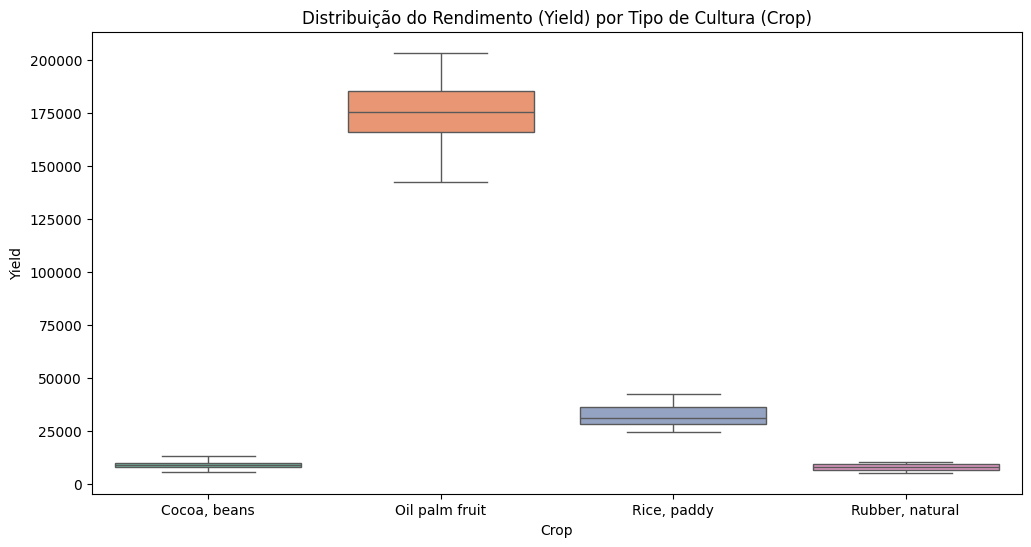

In [3]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustando o tamanho do grafico
plt.figure(figsize=(12, 6))

# Criando o gráfico de caixa para localizar os outliers do rendimento por cultura
sns.boxplot(data=tabela_fazenda, x='Crop', y='Yield', hue='Crop', palette='Set2')

# Titulo
plt.title('Distribuição do Rendimento (Yield) por Tipo de Cultura (Crop)')

plt.show()

Nesta etapa, utilizei um **gráfico de caixas (Boxplot)** para analisar a presença de possíveis outliers nos dados de rendimento das culturas.

Após a análise, observei que **não existem erros aparentes nos dados**, porém há uma **diferença muito grande na escala de produção entre as culturas**. A cultura **Oil palm fruit** apresenta rendimentos muito elevado, chegando perto de **200 mil toneladas**, enquanto culturas como **Cocoa** e **Rubber** possuem volumes significativamente menores.

Com isso, concluo que **o tipo de cultura influencia diretamente no rendimento**, explicando a grande variação observada no gráfico.

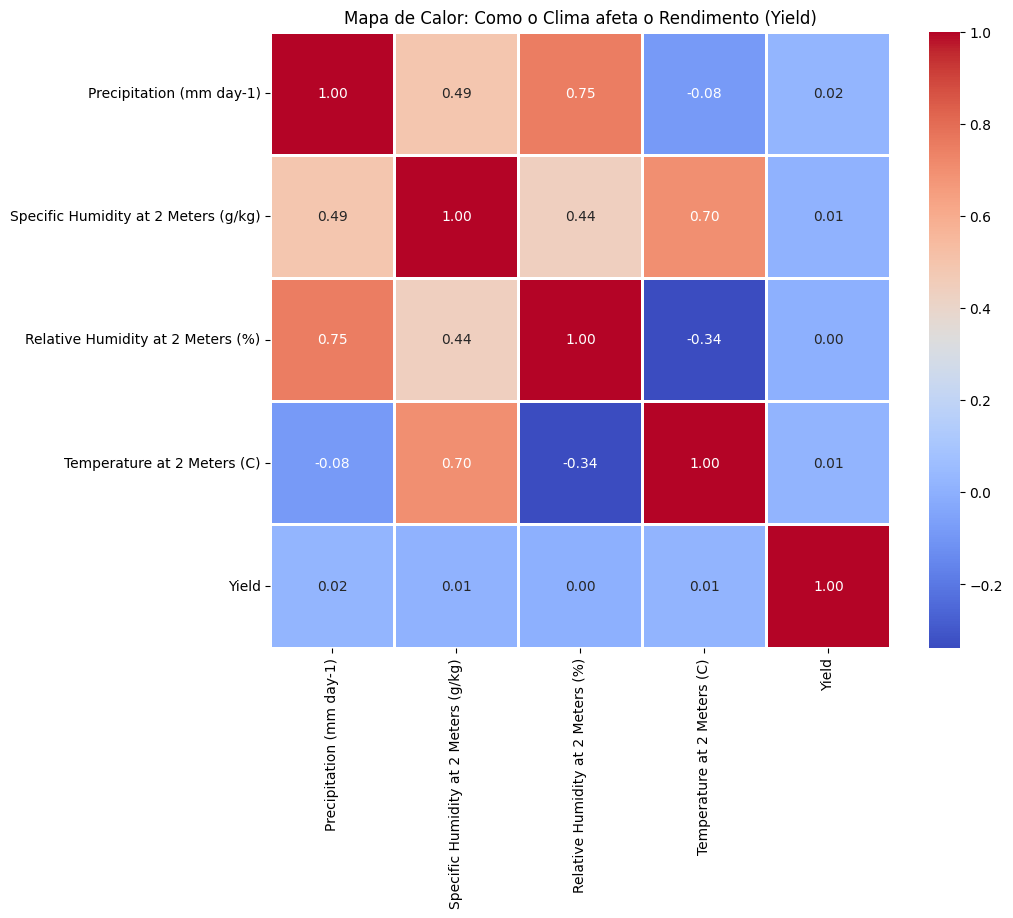

In [4]:
# Separando apenas as colunas que contêm números
colunas_numericas = tabela_fazenda.select_dtypes(include=['float64', 'int64'])

# Correlação entre todas essas variáveis
correlacao = colunas_numericas.corr()

plt.figure(figsize=(10, 8))

# Configurando o Mapa de Calor
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

# Titulo
plt.title('Mapa de Calor: Como o Clima afeta o Rendimento (Yield)')

plt.show()

## Correlação Climática

Nesta etapa, utilizei um **mapa de calor (Heatmap)** para analisar a correlação entre as variáveis climáticas e o rendimento das safras.

Ao observar os resultados, percebi um resultado interessante: **as variáveis de clima (chuva, temperatura e umidade) apresentaram correlação quase zero com o rendimento** quando analisamos a fazenda como um todo.

Isso acontece porque a variável **"Crop" (tipo de cultura)** possui um impacto muito maior na tonelagem final produzida. Dessa forma as diferenças de produtividade entre os tipos de culturas acabam **mascarando o efeito das variáveis climáticas** quando analisamos todos os dados juntos.

In [5]:
# Transformando a coluna de texto 'Crop' em colunas numéricas 0 e 1
# Utiliando o comando get_dummies
tabela_ml = pd.get_dummies(tabela_fazenda, columns=['Crop'], dtype=int)

display(tabela_ml.head())

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,"Crop_Cocoa, beans",Crop_Oil palm fruit,"Crop_Rice, paddy","Crop_Rubber, natural"
0,2248.92,17.72,83.40,26.01,11560,1,0,0,0
1,1938.42,17.54,82.11,26.11,11253,1,0,0,0
2,2301.54,17.81,82.79,26.24,9456,1,0,0,0
3,2592.35,17.61,85.07,25.56,9321,1,0,0,0
4,2344.72,17.61,84.12,25.76,8800,1,0,0,0


In [6]:
# Importando Train/Test
from sklearn.model_selection import train_test_split

# Separando as Pistas (X) da Resposta (y)
# Jogando fora (drop) apenas a coluna 'Yield'
X = tabela_ml.drop('Yield', axis=1)

# O y será a coluna Yield
y = tabela_ml['Yield']

# Dividindo os dados 80% para treino e 20% para teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Exibindo quantas linhas ficaram para cada lado
print(f"Quantidade de safras para a IA estudar (Treino): {X_treino.shape[0]}")
print(f"Quantidade de safras para a prova surpresa (Teste): {X_teste.shape[0]}")

Quantidade de safras para a IA estudar (Treino): 124
Quantidade de safras para a prova surpresa (Teste): 32


In [8]:
# Importando o modelo Regressão Linear
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
modelo_lr = LinearRegression()

# Entreguei o "caderno" (X_treino) e o "gabarito" (y_treino)
modelo_lr.fit(X_treino, y_treino)

# Pedi para ele adivinhar o rendimento das 32 linhas escondidas
previsoes_lr = modelo_lr.predict(X_teste)

# Corrigindo a prova e dando a nota final
erro_medio = mean_absolute_error(y_teste, previsoes_lr)
nota_r2 = r2_score(y_teste, previsoes_lr)

print("--- RESULTADOS DA REGRESSÃO LINEAR ---")
print(f"Erro Médio Absoluto (MAE): Errou por {erro_medio:.2f} toneladas em média.")
print(f"Score R² (A 'Nota' da prova): {nota_r2 * 100:.2f}% de acerto no padrão.")

--- RESULTADOS DA REGRESSÃO LINEAR ---
Erro Médio Absoluto (MAE): Errou por 3132.80 toneladas em média.
Score R² (A 'Nota' da prova): 99.50% de acerto no padrão.


## Modelo 1: Linear Regression

Ao aplicar o modelo de Regressão Linear, observei um desempenho muito alto. Isso acontece principalmente porque a variável que indica o tipo de cultura (como Cacau, Arroz ou Dendê) tem um impacto muito grande no rendimento final.

Com essa informação no conjunto de dados, o modelo consegue identificar padrões claros. Por exemplo, quando a cultura é Dendê, ele já entende que o rendimento esperado é muito alto, próximo de 180.000 toneladas.

O **Score R² de 99,50%** indica que o modelo conseguiu explicar praticamente toda a variação do rendimento das safras. Já o **Erro Médio Absoluto de 3132,80 toneladas** pode parecer grande, mas considerando culturas que podem produzir cerca de 200.000 toneladas, esse erro representa aproximadamente **1,5%**, o que é muito pequeno em relação à escala de produção.

In [9]:
#Importando segundo modelo, Árvore de Decisão
from sklearn.tree import DecisionTreeRegressor

# Usamos o random_state=42 para a árvore crescer sempre do mesmo jeito no meu PC e no do professor
modelo_dt = DecisionTreeRegressor(random_state=42)

# O momento do ESTUDO
modelo_dt.fit(X_treino, y_treino)

# Pedimos para ele adivinhar as mesmas 32 linhas escondidas
previsoes_dt = modelo_dt.predict(X_teste)

# Corrigindo a prova e dando a nota final
erro_medio_dt = mean_absolute_error(y_teste, previsoes_dt)
nota_r2_dt = r2_score(y_teste, previsoes_dt)

print("--- RESULTADOS DA ÁRVORE DE DECISÃO ---")
print(f"Erro Médio Absoluto (MAE): Errou por {erro_medio_dt:.2f} toneladas em média.")
print(f"Score R² (A 'Nota' da prova): {nota_r2_dt * 100:.2f}% de acerto no padrão.")

--- RESULTADOS DA ÁRVORE DE DECISÃO ---
Erro Médio Absoluto (MAE): Errou por 3440.69 toneladas em média.
Score R² (A 'Nota' da prova): 99.18% de acerto no padrão.


## Modelo 2: Decision Tree Regressor

Utilizei a Decision Tree Regressor como um segundo modelo para comparar os resultados obtidos com a Regressão Linear e verificar se outra abordagem de aprendizado conseguiria identificar os mesmos padrões nos dados.

O modelo apresentou **Score R² de 99,18%** e **Erro Médio Absoluto (MAE) de 3.440 toneladas**, mostrando um desempenho muito alto. Mesmo assim, ficou ligeiramente abaixo da Regressão Linear, indicando que pequenas variações nos dados podem afetar um pouco mais as previsões desse modelo.

In [10]:
# Importando terceiro modelo, Floresta Aleatória
from sklearn.ensemble import RandomForestRegressor

# continuando com o random_state
modelo_rf = RandomForestRegressor(random_state=42)

# O momento do ESTUDO
modelo_rf.fit(X_treino, y_treino)

# O momento da PROVA
previsoes_rf = modelo_rf.predict(X_teste)

# Corrigindo a prova e dando a nota final
erro_medio_rf = mean_absolute_error(y_teste, previsoes_rf)
nota_r2_rf = r2_score(y_teste, previsoes_rf)

print("--- RESULTADOS DA FLORESTA ALEATÓRIA ---")
print(f"Erro Médio Absoluto (MAE): Errou por {erro_medio_rf:.2f} toneladas em média.")
print(f"Score R² (A 'Nota' da prova): {nota_r2_rf * 100:.2f}% de acerto no padrão.")

--- RESULTADOS DA FLORESTA ALEATÓRIA ---
Erro Médio Absoluto (MAE): Errou por 2739.81 toneladas em média.
Score R² (A 'Nota' da prova): 99.42% de acerto no padrão.


## Modelo 3: Random Forest
Utilizei a Random Forest para testar um modelo baseado em **várias Árvores de Decisão trabalhando juntas**, buscando melhorar a precisão das previsões.

O modelo apresentou **Score R² de 99,42%**, ficando ligeiramente abaixo da Regressão Linear. Porém, obteve o **melhor Erro Médio Absoluto (MAE)** entre os modelos, com **2.739 toneladas**. Isso indica que, ao combinar várias árvores, o algoritmo consegue reduzir erros extremos e gerar previsões de rendimento mais consistentes.

In [11]:
# Importando o quarto modelo, SVR e a ferramenta que ajusta as escalas (StandardScaler)
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Arrumando a escala das nossas "Pistas" (X)
# Isso transforma números gigantes e pequenininhos em uma escala neutra e justa
scaler = StandardScaler()
X_treino_escalado = scaler.fit_transform(X_treino)
X_teste_escalado = scaler.transform(X_teste)

# Usei 'kernel=linear'para ele tentar achar uma linha reta nos dados
modelo_svr = SVR(kernel='linear')

# O momento do ESTUDO
modelo_svr.fit(X_treino_escalado, y_treino)

# O momento da PROVA
previsoes_svr = modelo_svr.predict(X_teste_escalado)

# Corrigindo a prova e dando a nota final
erro_medio_svr = mean_absolute_error(y_teste, previsoes_svr)
nota_r2_svr = r2_score(y_teste, previsoes_svr)

print("--- RESULTADOS DO SVR (Support Vector Regression) ---")
print(f"Erro Médio Absoluto (MAE): Errou por {erro_medio_svr:.2f} toneladas em média.")
print(f"Score R² (A 'Nota' da prova): {nota_r2_svr * 100:.2f}% de acerto no padrão.")

--- RESULTADOS DO SVR (Support Vector Regression) ---
Erro Médio Absoluto (MAE): Errou por 38804.37 toneladas em média.
Score R² (A 'Nota' da prova): -30.51% de acerto no padrão.


## Modelo 4: SVR

Utilizei o modelo **SVR** com o karnel='linear' para testar outra abordagem de regressão e comparar seu desempenho com os modelos anteriores. Antes do treinamento, foi necessário aplicar o **StandardScaler** para padronizar a escala das variáveis.

O resultado foi bastante fraco, com **Score R² de -30,51%** e **Erro Médio Absoluto superior a 38 mil toneladas**. Um R² negativo indica que o modelo teve desempenho pior do que simplesmente prever a média dos dados. Isso ocorreu porque o SVR linear não conseguiu lidar bem com as grandes diferenças de escala causadas pelo tipo de cultura, que geram saltos muito grandes no rendimento das safras.

In [15]:
# 1. Importando o quinto modelo, Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = GradientBoostingRegressor(random_state=42)

# 3. O momento do ESTUDO
modelo_gb.fit(X_treino, y_treino)
# 4. O momento da PROVA
previsoes_gb = modelo_gb.predict(X_teste)

# 5. Corrigindo a prova e dando a nota final
erro_medio_gb = mean_absolute_error(y_teste, previsoes_gb)
nota_r2_gb = r2_score(y_teste, previsoes_gb)

print("--- RESULTADOS DO GRADIENT BOOSTING ---")
print(f"Erro Médio Absoluto (MAE): Errou por {erro_medio_gb:.2f} toneladas em média.")
print(f"Score R² (A 'Nota' da prova): {nota_r2_gb * 100:.2f}% de acerto no padrão.")

--- RESULTADOS DO GRADIENT BOOSTING ---
Erro Médio Absoluto (MAE): Errou por 3066.41 toneladas em média.
Score R² (A 'Nota' da prova): 99.05% de acerto no padrão.


## Modelo 5: Gradient Boosting Regressor

Utilizei o **Gradient Boosting Regressor** para testar um modelo que aprende de forma sequencial, onde cada nova etapa tenta corrigir os erros da anterior, melhorando gradualmente as previsões.

O modelo apresentou **Score R² de 99,05%** e **Erro Médio Absoluto de 3.066 toneladas**, um desempenho muito alto. Porém, na base de dados utilizada, ele não conseguiu superar a precisão da **Floresta Aleatória**, que apresentou o menor erro médio entre os modelos testados. Isso ocorre pelo numero pequeno de linhas na planilha, oque faz o modelo ser treinado com pouco dado.

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

**## Conclusão do Projeto**

Após testar cinco modelos diferentes de Inteligência Artificial para prever o rendimento das safras da fazenda, foi possível comparar o desempenho de cada um deles e identificar qual apresentou os resultados mais consistentes.

Entre todos os algoritmos avaliados, o **Random Forest** apresentou o melhor equilíbrio entre precisão e confiabilidade nas previsões. Apesar da **Regressão Linear** ter alcançado um valor de R² ligeiramente maior, a Floresta Aleatória apresentou o **menor erro médio nas previsões**, indicando que suas estimativas de produção ficaram mais próximas da realidade.

Esse resultado é especialmente importante em um contexto agrícola, onde prever com maior precisão a quantidade de produção ajuda no planejamento da fazenda. Decisões como transporte da colheita, armazenamento e organização da logística dependem diretamente da estimativa de toneladas produzidas.

Outro ponto para observado ao longo da análise foi que **o tipo de cultura plantada exerce uma influência muito grande no rendimento final**, muito mais do que as variáveis climáticas quando analisamos os dados de forma geral. Culturas como o **Dendê (Oil Palm)** possuem uma produção muito maior que outras, como **Cacau ou Borracha**, o que explica grande parte da variação encontrada nos dados.

Dessa forma, considerando todos os testes realizados, o modelo de **Floresta Aleatória** se mostrou a melhor escolha para apoiar as previsões de produtividade da fazenda, oferecendo estimativas mais confiáveis para auxiliar no planejamento e na tomada de decisões.